$$
\begin{aligned}
\underset{\mathbf{x}}{\text{maximize}} \quad & \boldsymbol{\mu}^\top \mathbf{x} - \gamma \, \mathbf{x}^\top \Sigma \mathbf{x} \\
\text{subject to} \quad & \mathbf{1}^\top \mathbf{x} = 1, \\
& \mathbf{x} \geq \mathbf{0}.
\end{aligned}
$$


In [31]:
import datetime  
import yfinance as yf

In [32]:
start_date = datetime.datetime(2019, 9, 1)
end_date = datetime.datetime(2020, 9, 1)

tickers = [
    'KMX', 'CDW', 'VICI', 'NKE', 'RJF', 'ALK', 'MU', 'SRE', 'DOW',
    'DIS', 'SYY', 'IR', 'PODD', 'GE', 'ELV', 'MTB', 'VZ', 'FDS',
    'DG', 'AMGN', 'FTV', 'PRU', 'UNP', 'CMG', 'APTV', 'RMD', 'ALL',
    'PNW', 'CBRE', 'HLT'
]

data = yf.download(tickers, start=start_date, end=end_date)
daily_returns = (data['Close'] - data['Open']) / data['Open']

avg_return = daily_returns.mean()
cov_matrix = daily_returns.cov()

print(avg_return.head())
print(cov_matrix.head())

mu = avg_return.values
Sigma = cov_matrix.values

/var/folders/ht/879gb0f17j9__nx8w63714yw0000gn/T/ipykernel_17792/1280629218.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  30 of 30 completed

Ticker
ALK    -0.003721
ALL     0.000036
AMGN    0.001932
APTV   -0.000333
CBRE    0.000710
dtype: float64
Ticker       ALK       ALL      AMGN      APTV      CBRE       CDW       CMG  \
Ticker                                                                         
ALK     0.001044  0.000178 -0.000030  0.000346  0.000258  0.000179  0.000133   
ALL     0.000178  0.000393  0.000114  0.000215  0.000232  0.000200  0.000141   
AMGN   -0.000030  0.000114  0.000336  0.000003  0.000100  0.000140  0.000038   
APTV    0.000346  0.000215  0.000003  0.001069  0.000276  0.000200  0.000364   
CBRE    0.000258  0.000232  0.000100  0.000276  0.000797  0.000315  0.000196   

Ticker        DG       DIS       DOW  ...       PNW      PODD       PRU  \
Ticker                                ...                                 
ALK     0.000039  0.000257  0.000230  ...  0.000140 -0.000094  0.000314   
ALL     0.000068  0.000159  0.000140  ...  0.000160  0.000034  0.000212   
AMGN    0.000131  0.000095  0.00

In [33]:
max_stock = avg_return.idxmax()
min_stock = avg_return.idxmin()

print(f"Stock with highest mean return is {max_stock} with a return of {avg_return[max_stock]:.4f}.")
print(f"Stock with lowest mean return is {min_stock} with a return of {avg_return[min_stock]:.4f}.")

Stock with highest mean return is IR with a return of 0.0026.
Stock with lowest mean return is ALK with a return of -0.0037.


In [34]:
import cvxpy as cp

x = cp.Variable(len(mu))

# Risk aversion parameter
gamma = cp.Parameter(nonneg = True) 

# Objective
ret = mu.T@x
risk = cp.quad_form(x, Sigma)
obj = cp.Maximize(ret - gamma*risk)

# Constraints
cons = []
cons.append(cp.sum(x) == 1)
cons.append(x >= 0)

prob = cp.Problem(obj, cons)

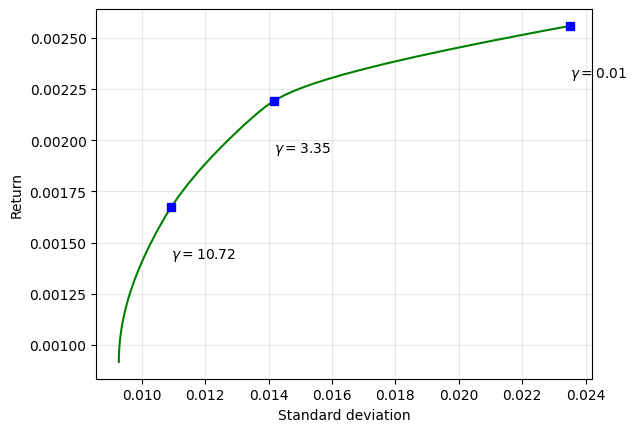

In [35]:
import numpy as np
import matplotlib.pyplot as plt

SAMPLES = 100
risk_data = np.zeros(SAMPLES)
ret_data = np.zeros(SAMPLES)
gamma_vals = np.logspace(-2, 3, num=SAMPLES)

for i, g in enumerate(gamma_vals):
    gamma.value = g
    prob.solve()
    risk_data[i] = cp.sqrt(risk).value
    ret_data[i] = ret.value

markers = [1, 50, 60]
fig, ax = plt.subplots()
ax.plot(risk_data, ret_data, 'g-')

for m in markers:
    ax.plot(risk_data[m], ret_data[m], 'bs')
    ax.annotate(rf"$\gamma = {gamma_vals[m]:.2f}$", xy=(risk_data[m], ret_data[m] - 0.00025))
    
ax.set_xlabel('Standard deviation')
ax.set_ylabel('Return')
ax.grid(alpha=0.3)
plt.show()


In [36]:
n_assets = len(mu)
weights = cp.Variable(n_assets)

portfolio_return = mu @ weights
portfolio_variance = cp.quad_form(weights, Sigma)

objective = cp.Minimize(portfolio_variance)

constraints = [
    cp.sum(weights) == 1,
    weights >= 0,
    portfolio_return >= 0.001
]

problem = cp.Problem(objective, constraints)
problem.solve()

weights_opt = np.round(weights.value, 3)
num_invested = np.count_nonzero(weights_opt)
expected_ret = portfolio_return.value
portfolio_var = objective.value

print(f"Optimal weights: {weights_opt}")
print(f"We are investing in {num_invested} stocks.")
print(f"The expected return of this portfolio is {expected_ret:.6f}")
print(f"The variance of this portfolio is {portfolio_var:.6f}")

Optimal weights: [-0.    -0.     0.071 -0.    -0.    -0.     0.     0.18  -0.    -0.
 -0.     0.     0.    -0.     0.129  0.08   0.    -0.     0.     0.004
 -0.     0.07  -0.    -0.     0.    -0.    -0.     0.091  0.019  0.357]
We are investing in 9 stocks.
The expected return of this portfolio is 0.001000
The variance of this portfolio is 0.000086


In [37]:
n_assets = len(mu)
x = cp.Variable(n_assets)

ret = mu @ x
risk = cp.quad_form(x, Sigma)
objective = cp.Minimize(risk)

constraints = [
    cp.sum(x) == 1,
    x >= 0
]

constraints += [x[i] <= 0 for i, val in enumerate(mu) if val < 0.001]

problem = cp.Problem(objective, constraints)
problem.solve()

x_opt = np.round(x.value, 3)
num_invested = np.count_nonzero(x_opt)
expected_ret = ret.value
portfolio_var = objective.value

print(f"Optimal weights: {x_opt}")
print(f"We are investing in {num_invested} stocks.")
print(f"The expected return of this portfolio is {expected_ret}")
print(f"The variance of the portfolio is {portfolio_var}")


Optimal weights: [ 0.     0.     0.269  0.     0.     0.    -0.    -0.     0.     0.
  0.     0.024  0.     0.     0.     0.096  0.029  0.     0.     0.223
  0.     0.109  0.     0.     0.     0.     0.     0.249  0.     0.   ]
We are investing in 7 stocks.
The expected return of this portfolio is 0.0015575763783942974
The variance of the portfolio is 0.00014866435874398267
